In [42]:
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd


In [43]:
df = pd.read_csv('/content/online_shoppers_intention.csv')
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [44]:
shoppers = fetch_ucirepo(id=468)

In [45]:
X = shoppers.data.features
y = shoppers.data.targets

In [46]:
df = pd.concat([X, y], axis=1)

In [47]:
print(f"Dataset Shape: {df.shape}")
print("\n--- First 5 Rows ---")
display(df.head())
print("\n--- Class Distribution of Revenue (Target) ---")
print(df['Revenue'].value_counts(normalize=True) * 100)

Dataset Shape: (12330, 18)

--- First 5 Rows ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



--- Class Distribution of Revenue (Target) ---
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Data Types ---")
print(df.dtypes)

--- Missing Values ---
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

--- Data Types ---
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Br

In [50]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

/tmp/ipykernel_2706/1152579064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Set2')


Text(0.5, 1.0, 'Page Values vs Revenue')

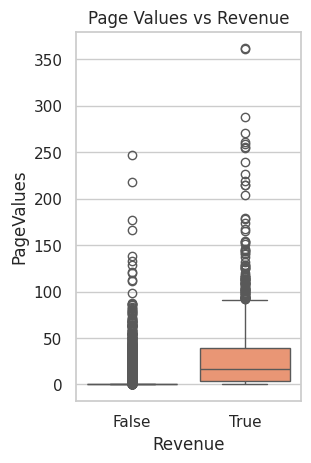

In [51]:
plt.subplot(1, 2, 1)
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='Set2')
plt.title('Page Values vs Revenue')


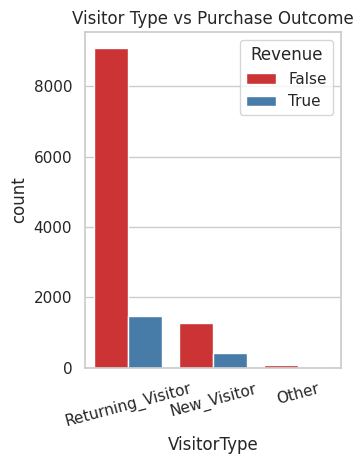

In [52]:
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='VisitorType', hue='Revenue', palette='Set1')
plt.title('Visitor Type vs Purchase Outcome')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [54]:
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

In [55]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [56]:
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print("\nPreprocessing and Splitting Complete!")

Training features shape: (9864, 26)
Testing features shape: (2466, 26)

Preprocessing and Splitting Complete!


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [60]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(random_state=42)

In [61]:
print("Training Logistic Regression...")
log_reg.fit(X_train_scaled, y_train)


Training Logistic Regression...


LogisticRegression(max_iter=1000, random_state=42)

In [62]:
print("Training Random Forest Classifier...")

Training Random Forest Classifier...


In [63]:
rf_model.fit(X_train_scaled, y_train)

print("\nModel Training Complete!")


Model Training Complete!


In [64]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [65]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [67]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Classifier": SVC(random_state=42)
}

In [68]:
model_performances = {}

for name, model in models.items():
    print(f"================ {name} ================")

    model.fit(X_train_scaled, y_train)


    y_pred = model.predict(X_test_scaled)


    acc = accuracy_score(y_test, y_pred)
    model_performances[name] = acc

    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

================ Logistic Regression ================
Accuracy: 0.8812

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

--------------------------------------------------
================ Decision Tree ================
Accuracy: 0.8637

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2084
           1       0.56      0.55      0.55       382

    accuracy                           0.86      2466
   macro avg       0.74      0.73      0.74      2466
weighted avg       0.86      0.86      0.86      2466

--------------------------------------------------
================ Random Forest ================
Accuracy: 0.8974

              precision    recall  f1-sc

In [69]:
print("\n========== Summary Comparison ==========")
for name, acc in sorted(model_performances.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")


========== Summary Comparison ==========
Random Forest: 0.8974
Support Vector Classifier: 0.8844
Logistic Regression: 0.8812
K-Nearest Neighbors: 0.8686
Decision Tree: 0.8637


In [70]:
print("--- Tuning Random Forest ---")
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

print(f"Best Parameters for Random Forest: {grid_rf.best_params_}")
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)
print("\nTuned Random Forest Performance:")
print(classification_report(y_test, y_pred_rf_tuned))


print("\n--- Tuning Support Vector Classifier (SVC) ---")

param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(SVC(random_state=42), param_grid_svc, cv=3, scoring='f1', n_jobs=-1)
grid_svc.fit(X_train_scaled, y_train)

print(f"Best Parameters for SVC: {grid_svc.best_params_}")
best_svc = grid_svc.best_estimator_
y_pred_svc_tuned = best_svc.predict(X_test_scaled)
print("\nTuned SVC Performance:")
print(classification_report(y_test, y_pred_svc_tuned))

--- Tuning Random Forest ---
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest Performance:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.55      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.78      2466
weighted avg       0.89      0.90      0.89      2466


--- Tuning Support Vector Classifier (SVC) ---
Best Parameters for SVC: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Tuned SVC Performance:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      2084
           1       0.68      0.49      0.57       382

    accuracy                           0.88      2466
   macro avg       0.79      0.72      0.75      2466
weighted avg       0.87      0.88      0.88      2466



In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

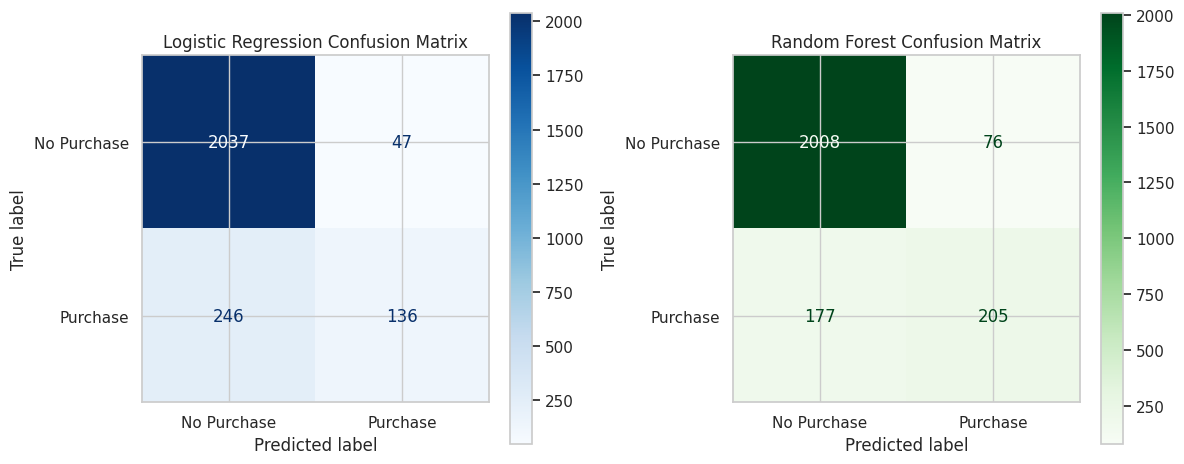

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test_scaled, y_test,
    ax=axes[0], cmap='Blues',
    display_labels=['No Purchase', 'Purchase']
)
axes[0].set_title('Logistic Regression Confusion Matrix')

ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test_scaled, y_test,
    ax=axes[1], cmap='Greens',
    display_labels=['No Purchase', 'Purchase']
)
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

In [73]:
importances = rf_model.feature_importances_
feature_names = X.columns

In [74]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [75]:
print("--- Top 10 Most Important Features ---")
print(feature_importance_df.head(10))

--- Top 10 Most Important Features ---
                    Feature  Importance
8                PageValues    0.364753
7                 ExitRates    0.091770
5   ProductRelated_Duration    0.089551
4            ProductRelated    0.070211
1   Administrative_Duration    0.059508
6               BounceRates    0.055887
0            Administrative    0.043518
13              TrafficType    0.031786
12                   Region    0.031015
3    Informational_Duration    0.025860


/tmp/ipykernel_2706/1842640344.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


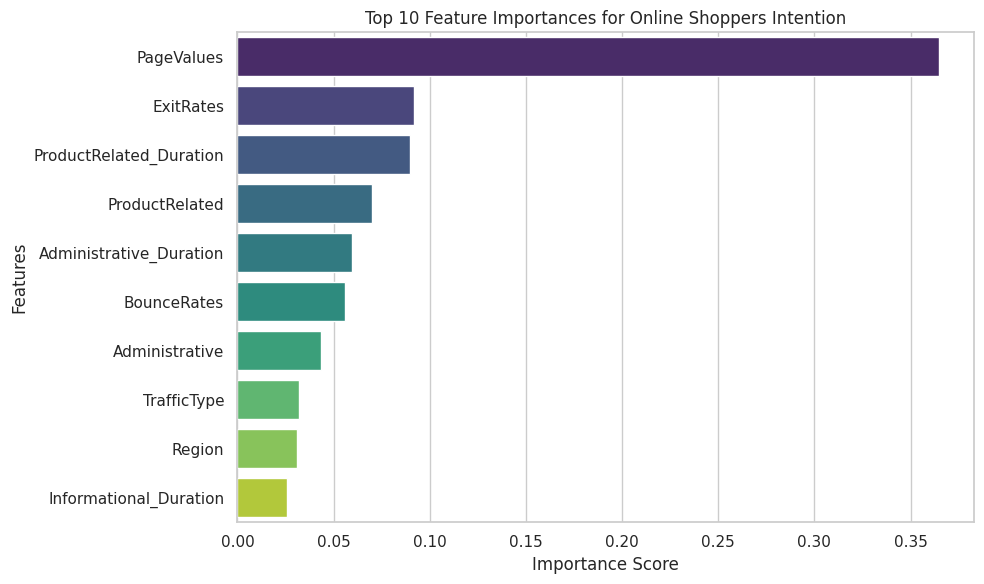

In [76]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances for Online Shoppers Intention')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [77]:
from sklearn.feature_selection import SelectFromModel

In [78]:
sfm = SelectFromModel(rf_model, threshold='mean')
sfm.fit(X_train_scaled, y_train)

SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                threshold='mean')

In [79]:
X_train_reduced = sfm.transform(X_train_scaled)
X_test_reduced = sfm.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Reduced number of features: {X_train_reduced.shape[1]}")

Original number of features: 26
Reduced number of features: 7


In [80]:
import joblib

joblib.dump(best_rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Model, scaler, and features saved successfully!")

Model, scaler, and features saved successfully!


In [86]:
!pip install -q streamlit joblib scikit-learn pandas
!npm install -g localtunnel > /dev/null 2>&1

In [91]:
app_code = """import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load the saved model, scaler, and features
model = joblib.load('random_forest_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_columns = joblib.load('model_features.pkl')

st.title("🛍️ Online Shoppers Purchasing Intention Predictor")
st.write("Enter the session metrics below to predict if the user will complete a purchase.")

# Create input fields for the most important features
page_values = st.number_input("Page Values (Average value of pages visited)", min_value=0.0, value=0.0)
exit_rates = st.number_input("Exit Rates (Average exit rate)", min_value=0.0, max_value=1.0, value=0.0)
product_duration = st.number_input("Product Related Duration (Seconds)", min_value=0.0, value=0.0)
product_related = st.number_input("Product Related Page Count", min_value=0, value=1)
bounce_rates = st.number_input("Bounce Rates (Average bounce rate)", min_value=0.0, max_value=1.0, value=0.0)

visitor_type = st.selectbox("Visitor Type", ["Returning_Visitor", "New_Visitor", "Other"])
weekend = st.checkbox("Is it a Weekend?")

if st.button("Predict Purchase Intention"):
    input_data = pd.DataFrame(0, index=[0], columns=feature_columns)

    input_data['PageValues'] = page_values
    input_data['ExitRates'] = exit_rates
    input_data['ProductRelated_Duration'] = product_duration
    input_data['ProductRelated'] = product_related
    input_data['BounceRates'] = bounce_rates
    input_data['Weekend'] = int(weekend)

    v_type_col = f"VisitorType_{visitor_type}"
    if v_type_col in input_data.columns:
        input_data[v_type_col] = 1

    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)
    prediction_proba = model.predict_proba(input_scaled)

    st.subheader("Prediction Result:")
    if prediction[0] == 1:
        st.success(f"🎉 **High Intent:** This session is likely to result in a **PURCHASE**! (Confidence: {prediction_proba[0][1]*100:.2f}%)")
    else:
        st.warning(f"🛒 **Low Intent:** This session is likely **NOT** to result in a purchase. (Confidence: {prediction_proba[0][0]*100:.2f}%)")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [94]:
!pip install -q pyngrok

In [96]:
import subprocess
import threading

# Kill any existing streamlit processes first
!pkill -f streamlit

# Run streamlit with CORS and XSRF disabled so localtunnel works smoothly
def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.port=8501", "--server.enableCORS=false", "--server.enableXsrfProtection=false"])

threading.Thread(target=run_streamlit, daemon=True).start()

import time
time.sleep(3) # Wait a moment for server to start
print("Streamlit server started in the background!")

Streamlit server started in the background!


In [98]:
!npx localtunnel --port 8501
import urllib.request
external_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip(('\n'))
print(f"Your Tunnel Password/IP is: {external_ip}")

⠙⠹⠸⠼⠴⠦your url is: https://fuzzy-nails-like.loca.lt
^C
Your Tunnel Password/IP is: 136.107.60.107


In [99]:
# 1. Download and install Cloudflare's tunneling tool
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1

import subprocess
import threading
import time

# 2. Make sure any old Streamlit servers are killed
!pkill -f streamlit

# 3. Start Streamlit in the background
def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.port=8501", "--server.enableCORS=false", "--server.enableXsrfProtection=false"])

threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(3) # Give it 3 seconds to spin up

# 4. Launch the Cloudflare Tunnel and grab the public URL
get_ipython().system_raw("cloudflared tunnel --url http://localhost:8501 &")

# 5. Extract and print the public trycloudflare.com link
import time
import re
time.sleep(4)
!grep -o 'https://[-0-9a-z]*\.trycloudflare.com' /root/.cloudflared/*.log 2>/dev/null || grep -o 'https://[-0-9a-z]*\.trycloudflare.com' nohup.out 2>/dev/null || echo "Check output logs or run cell again if link is pending."

Check output logs or run cell again if link is pending.


In [100]:
import subprocess
import threading
import time

# Kill any existing streamlit instances
!pkill -f streamlit

# Run streamlit with proxy support flags
def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.port=8501", "--server.enableCORS=false", "--server.enableXsrfProtection=false"])

threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(3)
print("✅ Streamlit app is running locally on port 8501!")

✅ Streamlit app is running locally on port 8501!


In [102]:
# 1. Install dependencies & download cloudflared binary
!pip install -q streamlit
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# 2. Launch Streamlit in background & connect Cloudflare tunnel
import subprocess, time, re

subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"])
tunnel = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
                          stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# 3. Print the live public URL
time.sleep(5)
url = None
for _ in range(20):
    line = tunnel.stderr.readline()
    match = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', line)
    if match:
        url = match.group(0)
        break
    time.sleep(0.5)

print("\n" + "=" * 55)
print(f"👉 CLICK HERE TO OPEN YOUR APP:\n{url}")
print("=" * 55)


👉 CLICK HERE TO OPEN YOUR APP:
https://propose-stable-lexington-spam.trycloudflare.com
